# 01 - Train an unconditional flow-matching model

Notebook `00` separated the source distribution, learned field, and sampler. We
now train the learned part: a small unconditional MLP that predicts velocity
along independently paired noise-to-data paths. The goal is not merely to lower
a loss curve, but to see whether local velocity predictions assemble into a
convincing global transport. We begin with three clusters, then reuse the same
training idea on a noisy circle and eight separated modes so that curved
support, missing modes, uneven occupancy, and incorrect spread become visible
rather than hidden inside one score.


In [1]:
import sys
from pathlib import Path

NOTES_DIR = Path.cwd()
if not (NOTES_DIR / "toy_notes.py").exists():
    NOTES_DIR = Path("notebooks/toy_data")
sys.path.insert(0, str(NOTES_DIR.resolve()))

from IPython import get_ipython

ipython = get_ipython()
if ipython is not None:
    ipython.run_line_magic("matplotlib", "inline")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from toy_notes import *

SEED = 2026
set_seed(SEED)
device = choose_device()
print(environment_summary(device))


{'torch': '2.9.1+cu128', 'device': 'cuda', 'gpu': 'NVIDIA RTX A6000', 'cuda': '12.8'}


## 1. Why train the model ourselves?

A pretrained checkpoint would hide the connection between sampled endpoint
pairs and the velocity loss. This small example lets us see the complete
training rule before using larger pretrained image models.

For each minibatch:

1. sample independent `x_noise` and `x_data`;
2. sample `t` uniformly from `[0,1]`;
3. form `x_t = t*x_data + (1-t)*x_noise`;
4. regress `v_theta(t,x_t)` onto `x_data - x_noise` with mean-squared error.

This is I-CFM. It is not optimal-transport CFM because we do not solve an
optimal coupling between noise and data samples.


In [2]:
# The helper implements the four lines above. Later notebooks reuse this model.
model, losses, _ = load_or_train_model(device=device)
print("parameters:", sum(p.numel() for p in model.parameters()))


parameters: 34050


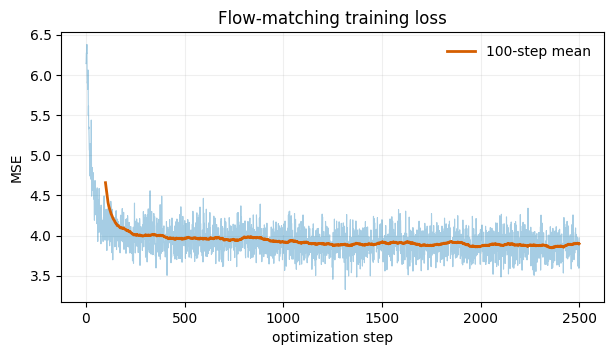

In [3]:
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(losses, color="#0072B2", alpha=0.35, lw=0.8)
if len(losses) >= 100:
    window = 100
    smooth = np.convolve(losses, np.ones(window) / window, mode="valid")
    ax.plot(np.arange(window - 1, len(losses)), smooth, color="#D55E00", lw=2, label="100-step mean")
    ax.legend(frameon=False)
ax.set(xlabel="optimization step", ylabel="MSE", title="Flow-matching training loss")
ax.grid(alpha=0.2)
plt.show()


## 2. How does a fitted field become samples?

Once an initial noise batch is fixed, the ODE sampler is deterministic:

$$\frac{dx}{dt}=v_\theta(t,x), \qquad x(0)=x_{noise}.$$

We use Heun's method here. Notebook `02` compares it with Euler and RK4.


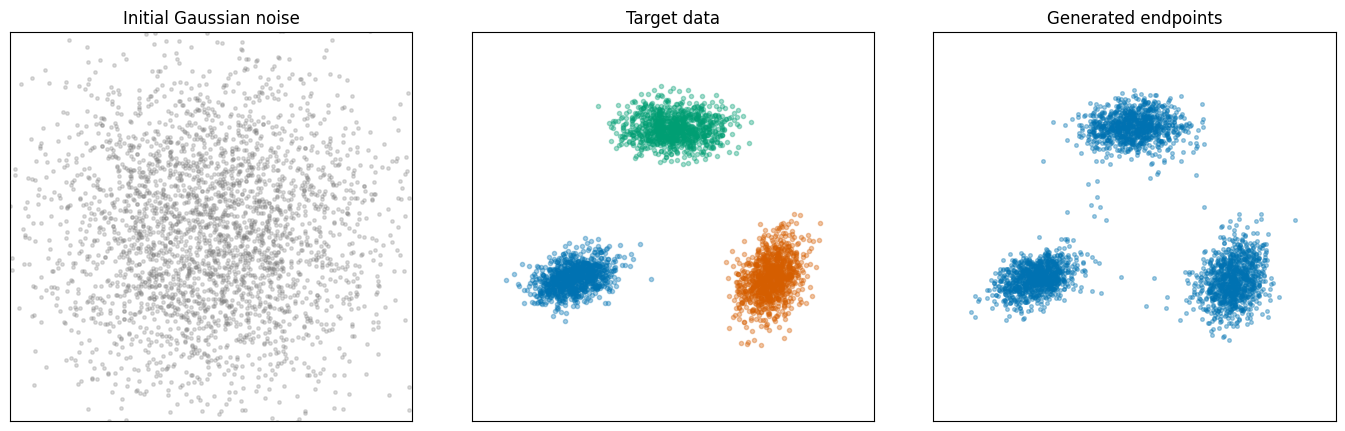

sampling time: 0.168 s


In [4]:
set_seed(SEED + 10)
x0_eval = sample_base(3000, device=device)
trajectory, sample_seconds = timed_sample(base_velocity(model), x0_eval, steps=80, method="heun")
generated = trajectory[-1].to(device)
target, target_labels = sample_labeled_mixture(3000, device=device)

fig, axes = plt.subplots(1, 3, figsize=(14, 4.3))
axes[0].scatter(x0_eval[:, 0].cpu(), x0_eval[:, 1].cpu(), s=6, alpha=0.25, color="#777777")
axes[0].set_title("Initial Gaussian noise")
plot_labeled_points(target, target_labels, ax=axes[1], title="Target data", alpha=0.35)
axes[2].scatter(generated[:, 0].cpu(), generated[:, 1].cpu(), s=7, alpha=0.35, color="#0072B2")
axes[2].set_title("Generated endpoints")
for ax in axes:
    ax.set_aspect("equal")
    ax.set_xlim(-4.5, 4.5)
    ax.set_ylim(-4.2, 4.5)
    ax.set_xticks([])
    ax.set_yticks([])
plt.tight_layout()
plt.show()
print(f"sampling time: {sample_seconds:.3f} s")


In [5]:
stats = estimate_gaussian_stats(target, target_labels)
predicted = predict_classes(generated, stats)
generated_balance = torch.bincount(predicted, minlength=len(CLASS_NAMES)).float()
generated_balance /= generated_balance.sum()

diagnostics = pd.DataFrame({
    "diagnostic": [
        "Wasserstein distance to full target",
        "generated class balance max error",
        "smallest generated mode fraction",
        "all samples finite",
    ],
    "value": [
        wasserstein_distance(generated, target),
        float(torch.max(torch.abs(generated_balance - 1 / len(CLASS_NAMES))).cpu()),
        float(generated_balance.min().cpu()),
        bool(torch.isfinite(generated).all()),
    ],
})
display(diagnostics)
print("generated class balance:", generated_balance.cpu().numpy().round(3))


,diagnostic,value
0,Wasserstein distance to full target,0.253774
1,generated class balance max error,0.001
2,smallest generated mode fraction,0.332333
3,all samples finite,True


generated class balance: [0.333 0.334 0.332]


### Why use Wasserstein distance in addition to a plot?

A class rate or a mean checks only one property. Wasserstein distance asks for
the cheapest way to match generated points to target points, where moving a
point farther costs more. The code uses equal-size deterministic subsets and
reports the mean matched distance. It is a finite-sample estimate, not the
unknown population distance.

The lines below make the definition literal. Lower is better. We still inspect
mode coverage and spread because one scalar cannot diagnose every failure.


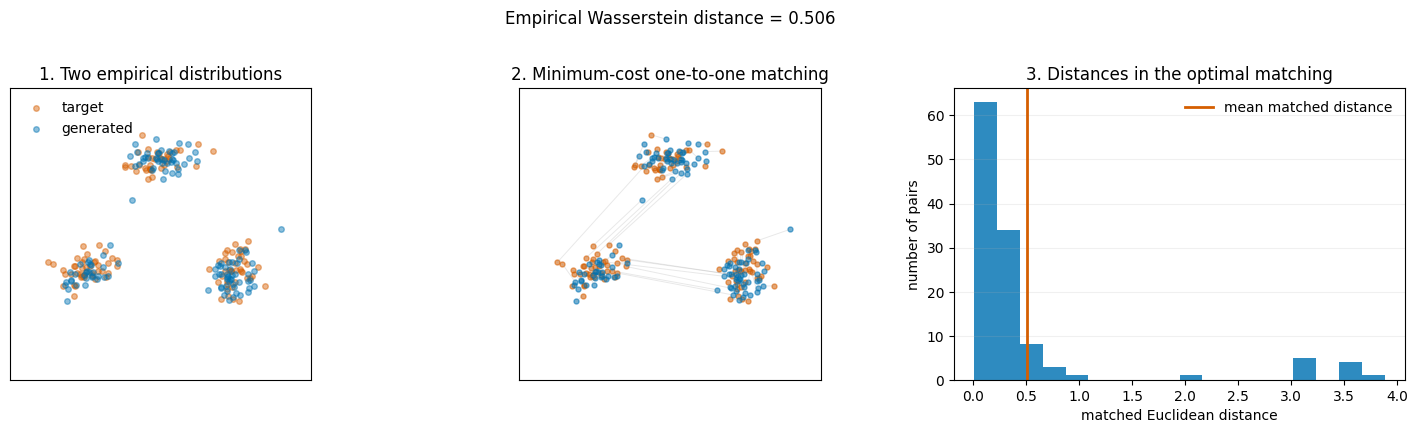

In [6]:
from scipy.optimize import linear_sum_assignment

visual_count = 120
visual_indexes = torch.linspace(0, generated.shape[0] - 1, visual_count).round().long().to(device)
target_indexes = torch.linspace(0, target.shape[0] - 1, visual_count).round().long().to(device)
visual_generated = generated[visual_indexes]
visual_target = target[target_indexes]
matching_costs = torch.cdist(visual_generated, visual_target).cpu().numpy()
generated_rows, target_columns = linear_sum_assignment(matching_costs)
matched_distances = matching_costs[generated_rows, target_columns]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
axes[0].scatter(
    visual_target[:, 0].cpu(), visual_target[:, 1].cpu(),
    s=16, alpha=0.45, color="#D55E00", label="target",
)
axes[0].scatter(
    visual_generated[:, 0].cpu(), visual_generated[:, 1].cpu(),
    s=16, alpha=0.45, color="#0072B2", label="generated",
)
axes[0].set(title="1. Two empirical distributions", aspect="equal", xlim=(-4.5, 4.5), ylim=(-4.2, 4.5))
axes[0].set_xticks([])
axes[0].set_yticks([])
axes[0].legend(frameon=False, loc="upper left")

for row, column in zip(generated_rows, target_columns):
    endpoints = torch.stack([visual_generated[row], visual_target[column]]).cpu()
    axes[1].plot(endpoints[:, 0], endpoints[:, 1], color="#999999", alpha=0.22, lw=0.7)
axes[1].scatter(visual_target[:, 0].cpu(), visual_target[:, 1].cpu(), s=13, alpha=0.55, color="#D55E00")
axes[1].scatter(visual_generated[:, 0].cpu(), visual_generated[:, 1].cpu(), s=13, alpha=0.55, color="#0072B2")
axes[1].set(title="2. Minimum-cost one-to-one matching", aspect="equal", xlim=(-4.5, 4.5), ylim=(-4.2, 4.5))
axes[1].set_xticks([])
axes[1].set_yticks([])

axes[2].hist(matched_distances, bins=18, color="#0072B2", alpha=0.82)
axes[2].axvline(matched_distances.mean(), color="#D55E00", lw=2, label="mean matched distance")
axes[2].set(title="3. Distances in the optimal matching", xlabel="matched Euclidean distance", ylabel="number of pairs")
axes[2].legend(frameon=False)
axes[2].grid(alpha=0.18, axis="y")

fig.suptitle(f"Empirical Wasserstein distance = {matched_distances.mean():.3f}", y=1.02)
plt.tight_layout()
plt.show()


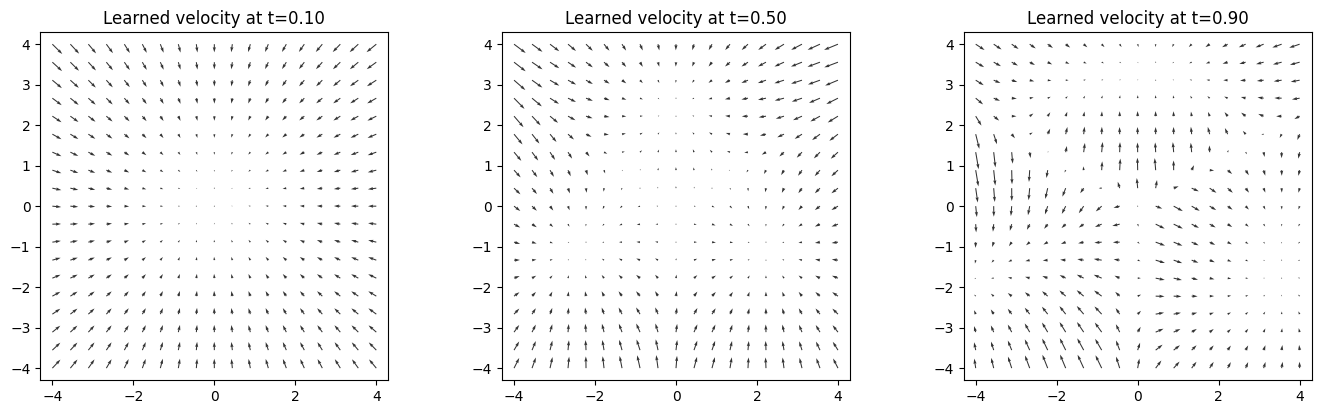

In [7]:
# A vector field is easier to understand when it is drawn.
grid_1d = torch.linspace(-4, 4, 19, device=device)
gx, gy = torch.meshgrid(grid_1d, grid_1d, indexing="xy")
grid = torch.stack([gx.reshape(-1), gy.reshape(-1)], dim=1)

fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
for ax, t_value in zip(axes, [0.10, 0.50, 0.90]):
    t = torch.full((grid.shape[0],), t_value, device=device)
    with torch.no_grad():
        vectors = model(t, grid)
    ax.quiver(
        grid[:, 0].cpu(), grid[:, 1].cpu(), vectors[:, 0].cpu(), vectors[:, 1].cpu(),
        angles="xy", scale_units="xy", scale=18, width=0.003, color="#333333",
    )
    ax.set_title(f"Learned velocity at t={t_value:.2f}")
    ax.set_aspect("equal")
    ax.set_xlim(-4.3, 4.3)
    ax.set_ylim(-4.3, 4.3)
plt.tight_layout()
plt.show()


## 3. Does the method learn a curved distribution?

Three Gaussian clusters could leave the impression that flow matching only
learns a few destination centers. A noisy circle is a stricter visual test: it
has continuously many valid endpoints and a thin curved support. We train a
separate unconditional model and ask whether it forms the ring without leaving
large angular gaps.


step    1/3000 | flow-matching loss 7.97199


step  500/3000 | flow-matching loss 5.13121


step 1000/3000 | flow-matching loss 5.30152


step 1500/3000 | flow-matching loss 5.18391


step 2000/3000 | flow-matching loss 4.97307


step 2500/3000 | flow-matching loss 5.01241


step 3000/3000 | flow-matching loss 4.84218


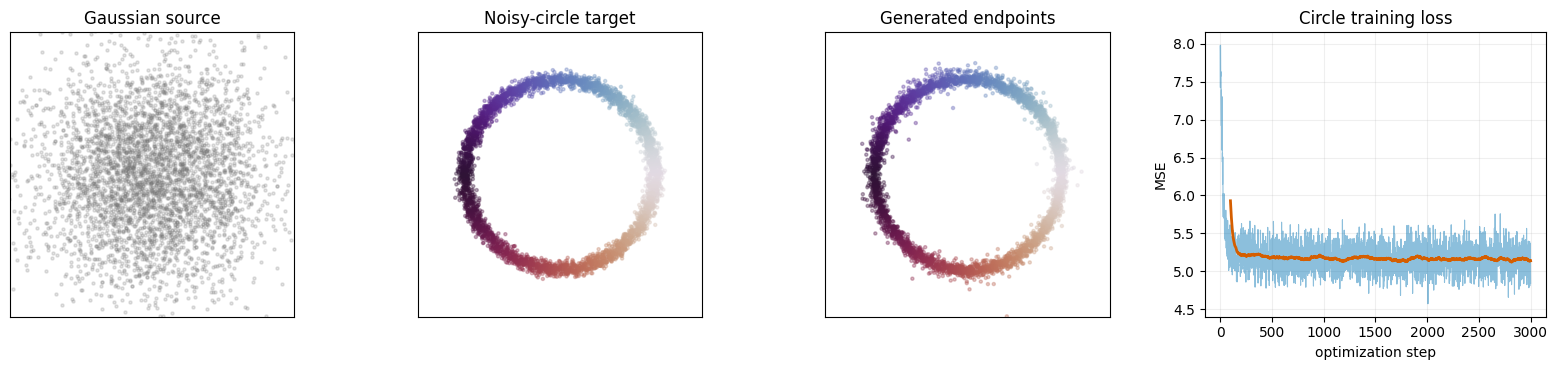

circle load/train seconds: 9.04
circle sampling seconds: 0.06


In [8]:
main_checkpoint_digest_before = file_sha256(CHECKPOINT_PATH)
circle_train_started = time.perf_counter()
circle_model, circle_losses, _ = load_or_train_circle_model(device=device)
circle_train_seconds = time.perf_counter() - circle_train_started
assert file_sha256(CHECKPOINT_PATH) == main_checkpoint_digest_before

set_seed(SEED + 71)
circle_x0 = sample_base(4096, device=device)
circle_target, _ = sample_noisy_circle(4096, device=device)
circle_sample_started = time.perf_counter()
circle_path = integrate_ode(base_velocity(circle_model), circle_x0, steps=80, method="heun")
circle_sample_seconds = time.perf_counter() - circle_sample_started
circle_generated = circle_path[-1].to(device)

target_angles = torch.remainder(torch.atan2(circle_target[:, 1], circle_target[:, 0]), 2 * np.pi)
generated_angles = torch.remainder(torch.atan2(circle_generated[:, 1], circle_generated[:, 0]), 2 * np.pi)

fig, axes = plt.subplots(1, 4, figsize=(16, 3.8))
axes[0].scatter(circle_x0[:, 0].cpu(), circle_x0[:, 1].cpu(), s=5, alpha=0.20, color="#777777")
axes[0].set_title("Gaussian source")
axes[1].scatter(circle_target[:, 0].cpu(), circle_target[:, 1].cpu(), c=target_angles.cpu(), cmap="twilight", s=5, alpha=0.35)
axes[1].set_title("Noisy-circle target")
axes[2].scatter(circle_generated[:, 0].cpu(), circle_generated[:, 1].cpu(), c=generated_angles.cpu(), cmap="twilight", s=5, alpha=0.35)
axes[2].set_title("Generated endpoints")
axes[3].plot(circle_losses, color="#0072B2", alpha=0.45, lw=0.8)
if len(circle_losses) >= 100:
    circle_smooth = np.convolve(circle_losses, np.ones(100) / 100, mode="valid")
    axes[3].plot(np.arange(99, len(circle_losses)), circle_smooth, color="#D55E00", lw=2)
axes[3].set(title="Circle training loss", xlabel="optimization step", ylabel="MSE")
axes[3].grid(alpha=0.2)
for ax in axes[:3]:
    ax.set(aspect="equal", xlim=(-4.5, 4.5), ylim=(-4.5, 4.5))
    ax.set_xticks([])
    ax.set_yticks([])
plt.tight_layout()
plt.show()
print(f"circle load/train seconds: {circle_train_seconds:.2f}")
print(f"circle sampling seconds: {circle_sample_seconds:.2f}")


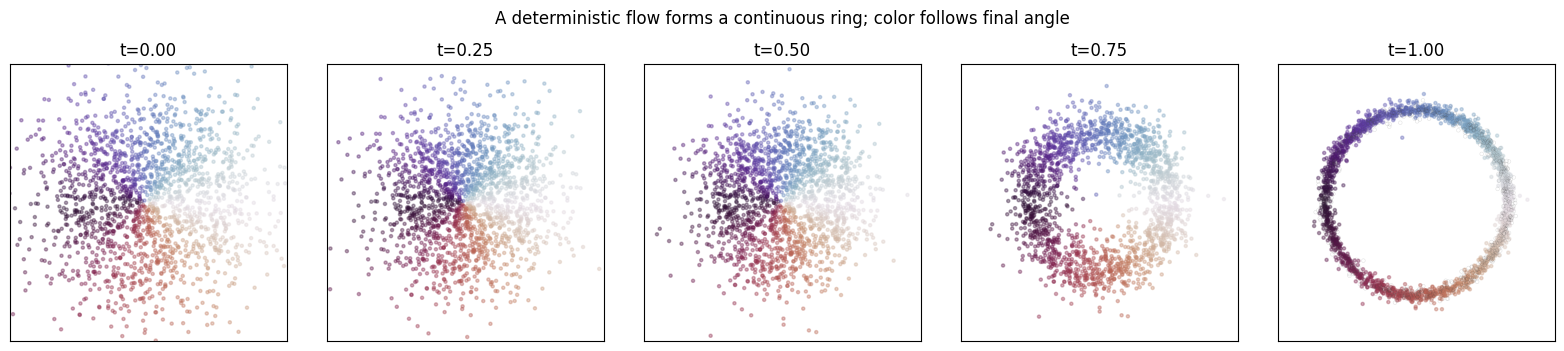

In [9]:
snapshot_steps = [0, 20, 40, 60, 80]
circle_plot_indexes = torch.linspace(0, circle_path.shape[1] - 1, 1800).round().long()
circle_final_colors = generated_angles[circle_plot_indexes.to(device)].cpu()

fig, axes = plt.subplots(1, len(snapshot_steps), figsize=(16, 3.4))
for ax, step_index in zip(axes, snapshot_steps):
    points = circle_path[step_index][circle_plot_indexes]
    ax.scatter(points[:, 0], points[:, 1], c=circle_final_colors, cmap="twilight", s=5, alpha=0.38)
    if step_index == 80:
        reference = circle_target[:900].cpu()
        ax.scatter(reference[:, 0], reference[:, 1], s=7, facecolors="none", edgecolors="#444444", alpha=0.15, linewidths=0.4)
    ax.set_title(f"t={step_index / 80:.2f}")
    ax.set(aspect="equal", xlim=(-4.5, 4.5), ylim=(-4.5, 4.5))
    ax.set_xticks([])
    ax.set_yticks([])
fig.suptitle("A deterministic flow forms a continuous ring; color follows final angle", y=1.02)
plt.tight_layout()
plt.show()


In [10]:
circle_target_radii = torch.linalg.norm(circle_target, dim=1)
circle_generated_radii = torch.linalg.norm(circle_generated, dim=1)
circle_radial_mae = float(torch.mean(torch.abs(circle_generated_radii - CIRCLE_RADIUS)).cpu())

angular_bins = 16
target_bins = torch.floor(angular_bins * target_angles / (2 * np.pi)).long().clamp_max(angular_bins - 1)
generated_bins = torch.floor(angular_bins * generated_angles / (2 * np.pi)).long().clamp_max(angular_bins - 1)
target_occupancy = torch.bincount(target_bins, minlength=angular_bins).float()
target_occupancy /= target_occupancy.sum()
generated_occupancy = torch.bincount(generated_bins, minlength=angular_bins).float()
generated_occupancy /= generated_occupancy.sum()
circle_angular_tv = float((0.5 * torch.abs(generated_occupancy - target_occupancy).sum()).cpu())

circle_source_wasserstein = wasserstein_distance(circle_x0, circle_target)
circle_generated_wasserstein = wasserstein_distance(circle_generated, circle_target)
circle_wasserstein_ratio = circle_generated_wasserstein / circle_source_wasserstein

circle_diagnostics = pd.DataFrame({
    "diagnostic": [
        "target mean radius", "generated mean radius", "generated radial MAE",
        "angular occupancy total variation", "source-to-target Wasserstein distance",
        "generated-to-target Wasserstein distance", "generated/source distance ratio",
    ],
    "value": [
        float(circle_target_radii.mean().cpu()), float(circle_generated_radii.mean().cpu()),
        circle_radial_mae, circle_angular_tv, circle_source_wasserstein,
        circle_generated_wasserstein, circle_wasserstein_ratio,
    ],
})
display(circle_diagnostics.round(4))


,diagnostic,value
0,target mean radius,3.0022
1,generated mean radius,3.0028
2,generated radial MAE,0.0968
3,angular occupancy total variation,0.0332
4,source-to-target Wasserstein distance,1.1061
5,generated-to-target Wasserstein distance,0.3925
6,generated/source distance ratio,0.3549


## 4. Why also inspect eight separated modes?

The three-class model is kept for the steering notebooks because its labels are
easy to discuss, while the circle tests continuous curved geometry. Eight narrow
components expose a different failure mode: a model can omit destinations or
assign them the wrong amount of probability. This is still learned I-CFM; no
destination center is used by the sampler.

We color each particle by the component nearest to its **final** endpoint, then
trace the same particle backward through stored time slices. The colors are for
reading the map after sampling; the model never receives them.


step    1/3000 | flow-matching loss 8.41816


step  500/3000 | flow-matching loss 5.52332


step 1000/3000 | flow-matching loss 5.31377


step 1500/3000 | flow-matching loss 5.66352


step 2000/3000 | flow-matching loss 5.69112


step 2500/3000 | flow-matching loss 5.50004


step 3000/3000 | flow-matching loss 5.26731


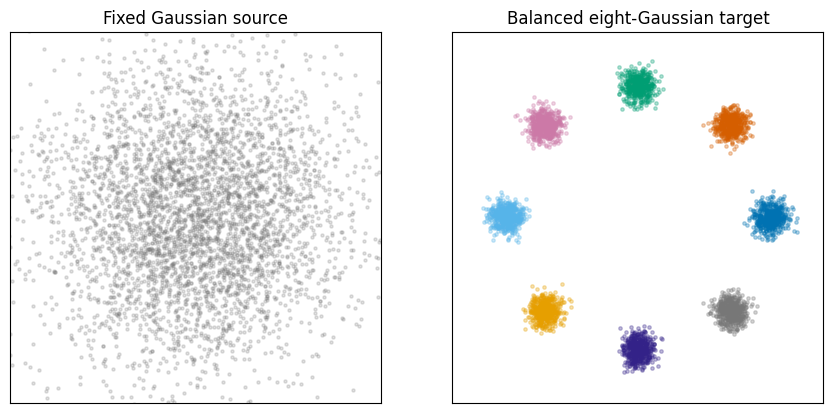

eight-mode sampling seconds: 0.053


In [11]:
import time

main_checkpoint_digest_before = file_sha256(CHECKPOINT_PATH)
ring_model, _, _ = load_or_train_eight_gaussian_model(device=device)
assert file_sha256(CHECKPOINT_PATH) == main_checkpoint_digest_before

set_seed(SEED + 81)
ring_x0 = sample_base(4096, device=device)
ring_target_labels = torch.arange(8, device=device).repeat_interleave(512)
ring_target, ring_target_labels = sample_eight_gaussians(
    ring_target_labels.numel(), device=device, labels=ring_target_labels
)

fig, axes = plt.subplots(1, 2, figsize=(9, 4.2))
axes[0].scatter(ring_x0[:, 0].cpu(), ring_x0[:, 1].cpu(), s=5, alpha=0.22, color="#777777")
axes[0].set_title("Fixed Gaussian source")
for component in range(8):
    points = ring_target[ring_target_labels == component].cpu()
    axes[1].scatter(points[:, 0], points[:, 1], s=6, alpha=0.30, color=EIGHT_GAUSSIAN_COLORS[component])
axes[1].set_title("Balanced eight-Gaussian target")
for ax in axes:
    ax.set(aspect="equal", xlim=(-4.5, 4.5), ylim=(-4.5, 4.5))
    ax.set_xticks([])
    ax.set_yticks([])
plt.tight_layout()
plt.show()

ring_sample_started = time.perf_counter()
ring_path = integrate_ode(base_velocity(ring_model), ring_x0, steps=80, method="heun")
ring_sample_seconds = time.perf_counter() - ring_sample_started
ring_generated = ring_path[-1].to(device)
ring_centers = EIGHT_GAUSSIAN_CENTERS.to(device)
ring_assignments = torch.cdist(ring_generated, ring_centers).argmin(dim=1)
print(f"eight-mode sampling seconds: {ring_sample_seconds:.3f}")


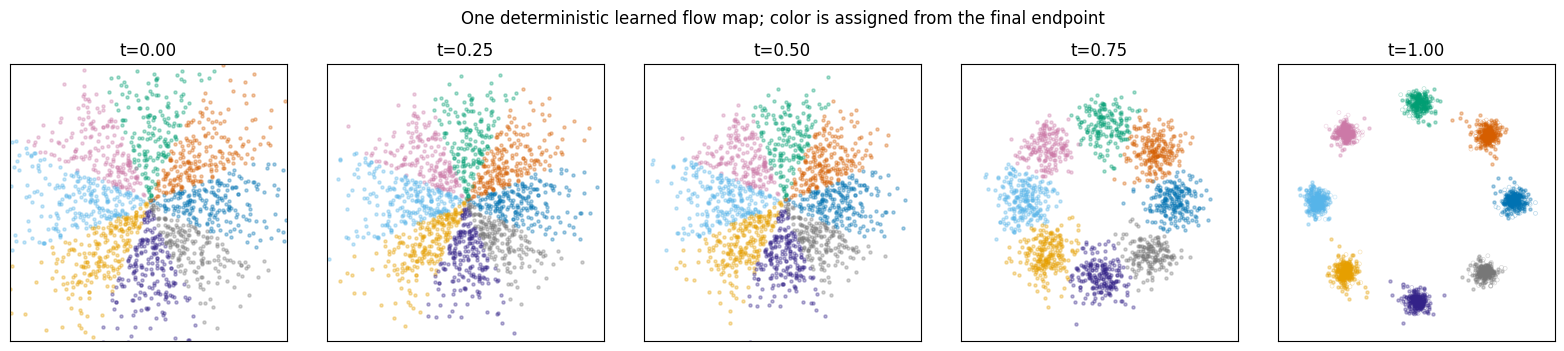

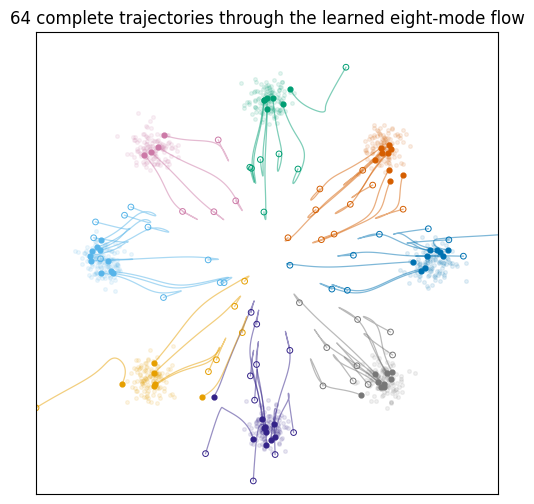

In [12]:
snapshot_steps = [0, 20, 40, 60, 80]
plot_indexes = torch.linspace(0, ring_path.shape[1] - 1, 1600).long()
plot_assignments = ring_assignments[plot_indexes.to(device)].cpu()
fig, axes = plt.subplots(1, len(snapshot_steps), figsize=(16, 3.4))
for ax, step_index in zip(axes, snapshot_steps):
    for component in range(8):
        mask = plot_assignments == component
        points = ring_path[step_index][plot_indexes][mask]
        ax.scatter(
            points[:, 0], points[:, 1], s=5, alpha=0.33,
            color=EIGHT_GAUSSIAN_COLORS[component],
        )
        if step_index == 80:
            reference = ring_target[ring_target_labels == component][:90].detach().cpu()
            ax.scatter(
                reference[:, 0], reference[:, 1], s=8, facecolors="none", alpha=0.28,
                edgecolors=EIGHT_GAUSSIAN_COLORS[component], linewidths=0.5,
            )
    ax.set_title(f"t={step_index / 80:.2f}")
    ax.set_aspect("equal")
    ax.set_xlim(-4.5, 4.5)
    ax.set_ylim(-4.5, 4.5)
    ax.set_xticks([])
    ax.set_yticks([])
fig.suptitle("One deterministic learned flow map; color is assigned from the final endpoint", y=1.02)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(6.2, 6.0))
for component in range(8):
    reference = ring_target[ring_target_labels == component][:120].detach().cpu()
    ax.scatter(reference[:, 0], reference[:, 1], s=7, alpha=0.10, color=EIGHT_GAUSSIAN_COLORS[component])
indexes = torch.linspace(0, ring_path.shape[1] - 1, 64).long()
for index in indexes:
    index = int(index)
    component = int(ring_assignments[index].cpu())
    ax.plot(
        ring_path[:, index, 0], ring_path[:, index, 1],
        color=EIGHT_GAUSSIAN_COLORS[component], alpha=0.50, lw=0.9,
    )
    ax.scatter(ring_path[0, index, 0], ring_path[0, index, 1], s=17, facecolors="none", edgecolors=EIGHT_GAUSSIAN_COLORS[component], linewidths=0.7)
    ax.scatter(ring_path[-1, index, 0], ring_path[-1, index, 1], s=12, color=EIGHT_GAUSSIAN_COLORS[component])
ax.set(title="64 complete trajectories through the learned eight-mode flow", aspect="equal", xlim=(-4.5, 4.5), ylim=(-4.5, 4.5))
ax.set_xticks([])
ax.set_yticks([])
plt.show()


In [13]:
generated_counts = torch.bincount(ring_assignments, minlength=8).float()
generated_fractions = generated_counts / generated_counts.sum()
target_assignments = torch.cdist(ring_target, ring_centers).argmin(dim=1)
target_counts = torch.bincount(target_assignments, minlength=8).float()
target_fractions = target_counts / target_counts.sum()

uniform_fractions = torch.full_like(generated_fractions, 1 / 8)
occupancy_tv = float((0.5 * torch.abs(generated_fractions - uniform_fractions).sum()).cpu())
source_wasserstein = wasserstein_distance(ring_x0, ring_target)
ring_wasserstein = wasserstein_distance(ring_generated, ring_target)
ring_wasserstein_ratio = ring_wasserstein / source_wasserstein
covered_modes = int((generated_fractions >= 0.05).sum().cpu())

mode_rows = []
for component in range(8):
    generated_mode = ring_generated[ring_assignments == component]
    target_mode = ring_target[ring_target_labels == component]
    target_mean = target_mode.mean(dim=0)
    target_rms = torch.sqrt((target_mode - target_mean).square().sum(dim=1).mean())
    centroid_error = torch.linalg.norm(generated_mode.mean(dim=0) - target_mean) / target_rms.clamp_min(1e-8)
    generated_trace = torch.var(generated_mode, dim=0, unbiased=False).sum()
    target_trace = torch.var(target_mode, dim=0, unbiased=False).sum()
    mode_rows.append({
        "mode": component,
        "generated share": float(generated_fractions[component].cpu()),
        "target share": float(target_fractions[component].cpu()),
        "normalized centroid error": float(centroid_error.cpu()),
        "within-mode trace ratio": float((generated_trace / target_trace).cpu()),
    })
mode_table = pd.DataFrame(mode_rows)
display(mode_table.round(3))

ring_diagnostics = pd.DataFrame({
    "diagnostic": [
        "modes with at least 5% generated mass",
        "occupancy total variation from uniform",
        "source-to-target Wasserstein distance",
        "generated-to-target Wasserstein distance",
        "generated/source Wasserstein distance ratio",
        "mean normalized centroid error",
        "median within-mode trace ratio",
        "all endpoints finite",
    ],
    "value": [
        covered_modes,
        occupancy_tv,
        source_wasserstein,
        ring_wasserstein,
        ring_wasserstein_ratio,
        mode_table["normalized centroid error"].mean(),
        mode_table["within-mode trace ratio"].median(),
        bool(torch.isfinite(ring_generated).all()),
    ],
})
display(ring_diagnostics.round(4))
print("generated occupancy:", generated_fractions.cpu().numpy().round(3))
print("target occupancy:   ", target_fractions.cpu().numpy().round(3))


,mode,generated share,target share,normalized centroid error,within-mode trace ratio
0,0,0.130,0.125,0.343,0.912
1,1,0.125,0.125,0.264,1.253
2,2,0.121,0.125,0.244,1.375
3,3,0.117,0.125,0.138,0.907
4,4,0.139,0.125,0.147,1.036
5,5,0.130,0.125,0.226,1.363
6,6,0.124,0.125,0.019,1.150
7,7,0.114,0.125,0.158,0.833


,diagnostic,value
0,modes with at least 5% generated mass,8
1,occupancy total variation from uniform,0.024414
2,source-to-target Wasserstein distance,1.238301
3,generated-to-target Wasserstein distance,0.27775
4,generated/source Wasserstein distance ratio,0.2243
5,mean normalized centroid error,0.192323
6,median within-mode trace ratio,1.092918
7,all endpoints finite,True


generated occupancy: [0.13  0.125 0.121 0.117 0.139 0.13  0.124 0.114]
target occupancy:    [0.125 0.125 0.125 0.125 0.125 0.125 0.125 0.125]


The snapshot figure shows **where the learned ODE sends regions of the initial
Gaussian**, while the diagnostics describe mode coverage, occupancy, and
within-mode spread. No single plot or scalar captures every mismatch between
the generated and target distributions.


## From a trained field to a denoised estimate

**Questions**

1. Why can a low minibatch MSE coexist with visibly poor samples?
2. What information about class identity did the unconditional model receive?
3. At which time does the vector field mostly choose coarse destination modes?

These examples show why training loss is only the beginning of the story. The
circle and eight-mode models are diagnostic detours: they reveal
curved-support and occupancy failures, while the remaining toy notes return to
the three-cluster model for class-level steering. With one trained field in
hand, Notebook `02` asks how to read its prediction as a denoised estimate and
how faithfully different deterministic solvers follow the same field.
